# 深度学习 作业 1

**学号：** 20234080203　**姓名：** 叶平

本 notebook 包含各题**理论解答**（Markdown）与**编程题**（需运行并查看打印输出）。

---
## 2 概述、线性代数和 NDArray

### 2.1 理论计算题

已知 $\mathbf{a} = [2, -1, 3]^\top$，$\mathbf{b} = [1, 4, -2]^\top$。

题目中矩阵排版在 PDF 中为多块拼接，这里按 **$A$ 为 $2\times 3$、$B$ 为 $3\times 2$** 理解（与“$A\times B$ 的形状”一问一致）：

$$
A = \begin{bmatrix} 2 & 1 & 1 \\ 1 & 0 & 2 \end{bmatrix},\quad
B = \begin{bmatrix} 0 & -1 \\ -1 & 3 \\ 3 & 2 \end{bmatrix}
$$

（若你课堂上的原题矩阵与此不同，只需在下面代码里改 `A`、`B` 即可。）

**1. 向量点积** $\mathbf{a}\cdot\mathbf{b}$

$$
\mathbf{a}\cdot\mathbf{b} = 2\cdot 1 + (-1)\cdot 4 + 3\cdot(-2) = 2 - 4 - 6 = -8.
$$

**2. 矩阵乘法** $C = AB$

$A$ 为 $2\times 3$，$B$ 为 $3\times 2$，故 $C$ 为 **$2\times 2$**。

按行乘列：$c_{11}=2\cdot0+1\cdot(-1)+1\cdot3=2$，$c_{12}=2\cdot(-1)+1\cdot3+1\cdot2=3$，$c_{21}=0+0+6=6$，$c_{22}=-1+0+4=3$，即

$$
C = \begin{bmatrix} 2 & 3 \\ 6 & 3 \end{bmatrix}.
$$

**3. $\mathbf{a}$ 的 Frobenius 范数**（与向量 $\ell_2$ 范数一致）

$$
\|\mathbf{a}\|_F = \sqrt{2^2+(-1)^2+3^2} = \sqrt{14}.
$$

### 2.2 编程题（NumPy）

In [1]:
import numpy as np

rng = np.random.default_rng(42)

# 1. 3×4 标准正态随机矩阵 X
X = rng.standard_normal(size=(3, 4))
print("X shape:", X.shape)
print("X =\n", X)

# 2. 4×2 全 1 矩阵 Y
Y = np.ones((4, 2))
print("\nY shape:", Y.shape)
print("Y =\n", Y)

# 3. Z = X @ Y
Z = X @ Y
print("\nZ = X @ Y, shape:", Z.shape)
print("Z =\n", Z)

# 4. 第一行与第二列交叉处元素；第 2 行全部元素
elem_12 = Z[0, 1]
row2 = Z[1, :]
print("\nZ[0,1] (第1行第2列):", elem_12)
print("Z[1,:] (第2行):", row2)

# 5. Z 的 Frobenius 范数
fz = np.linalg.norm(Z, ord="fro")
print("\n||Z||_F =", fz)

X shape: (3, 4)
X =
 [[ 0.30471708 -1.03998411  0.7504512   0.94056472]
 [-1.95103519 -1.30217951  0.1278404  -0.31624259]
 [-0.01680116 -0.85304393  0.87939797  0.77779194]]

Y shape: (4, 2)
Y =
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z = X @ Y, shape: (3, 2)
Z =
 [[ 0.95574889  0.95574889]
 [-3.44161688 -3.44161688]
 [ 0.78734483  0.78734483]]

Z[0,1] (第1行第2列): 0.955748885711607
Z[1,:] (第2行): [-3.44161688 -3.44161688]

||Z||_F = 5.172638511887385


---
## 3 概率与统计

### 3.1 理论计算题（贝叶斯公式）

记 $D$：患病，$+$：检测阳性。已知 $P(D)=0.001$，$P(+\mid D)=0.99$，$P(+\mid D^c)=0.02$。

由全概率公式：
$$
P(+) = P(+\mid D)P(D) + P(+\mid D^c)P(D^c)
 = 0.99\times 0.001 + 0.02\times 0.999.
$$

贝叶斯公式：
$$
P(D\mid +) = \frac{P(+\mid D)P(D)}{P(+)}.
$$

代入数值即可（见下格打印）。

In [2]:
p_d = 1e-3
p_pos_given_d = 0.99
p_pos_given_not_d = 0.02
p_pos = p_pos_given_d * p_d + p_pos_given_not_d * (1 - p_d)
p_d_given_pos = p_pos_given_d * p_d / p_pos
print("P(阳性) =", p_pos)
print("P(患病|阳性) =", p_d_given_pos)

P(阳性) = 0.020970000000000003
P(患病|阳性) = 0.047210300429184546


### 3.2 编程题（中心极限定理模拟）

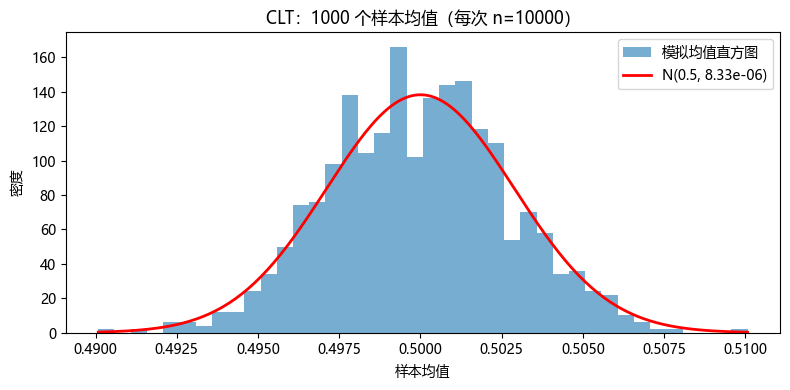

1000 个均值的样本方差: 7.694004196155086e-06
理论 Var(均值) = 1/(12n) = 8.333333333333334e-06


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from pathlib import Path

def _use_chinese_font():
    plt.rcParams["axes.unicode_minus"] = False
    for fp in ("C:/Windows/Fonts/msyh.ttc", "C:/Windows/Fonts/simhei.ttf", "C:/Windows/Fonts/simsun.ttc"):
        p = Path(fp)
        if p.is_file():
            try:
                fm.fontManager.addfont(str(p))
                name = fm.FontProperties(fname=str(p)).get_name()
                plt.rcParams["font.sans-serif"] = [name]
                plt.rcParams["font.family"] = name
                return
            except Exception:
                pass
    for f in fm.fontManager.ttflist:
        if any(k in f.name for k in ("YaHei", "SimHei", "SimSun")):
            plt.rcParams["font.sans-serif"] = [f.name]
            return


_use_chinese_font()

n = 10_000
m = 1000
rng = np.random.default_rng(0)

# 1. m 次，每次 n 个 U(0,1)，记录样本均值
means = np.empty(m)
for i in range(m):
    u = rng.uniform(0.0, 1.0, size=n)
    means[i] = u.mean()

# 理论：U(0,1) 均值 1/2，方差 1/12；样本均值 ~ 近似 N(1/2, 1/(12n))
mu = 0.5
sigma = np.sqrt(1 / (12 * n))

# 2. 直方图 + 理论正态密度
plt.figure(figsize=(8, 4))
counts, bins, _ = plt.hist(means, bins=40, density=True, alpha=0.6, label="模拟均值直方图")
xs = np.linspace(means.min(), means.max(), 200)
pdf = np.exp(-0.5 * ((xs - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
plt.plot(xs, pdf, "r-", lw=2, label=f"N({mu}, {sigma**2:.2e})")
plt.xlabel("样本均值")
plt.ylabel("密度")
plt.legend()
plt.title("CLT：1000 个样本均值（每次 n=10000）")
plt.tight_layout()
plt.show()

# 3. 实际方差
print("1000 个均值的样本方差:", means.var(ddof=1))
print("理论 Var(均值) = 1/(12n) =", 1 / (12 * n))

---
## 4 导数、反向传播和复杂度

### 4.1 理论计算题

设 $z = (w_1 x_1 + w_2 x_2 - y)^2$，其中 $x_1=2,x_2=1,y=3$，记 $s = 2w_1+w_2-3$，则 $z=s^2$。

$$
\frac{\partial z}{\partial w_1} = 2s \cdot \frac{\partial s}{\partial w_1} = 2(2w_1+w_2-3)\cdot 2 = 4(2w_1+w_2-3),
$$
$$
\frac{\partial z}{\partial w_2} = 2s \cdot \frac{\partial s}{\partial w_2} = 2(2w_1+w_2-3).
$$

当 $w_1=0.5,\,w_2=1$ 时，$s=1+1-3=-1$，故 $\partial z/\partial w_1=-4$，$\partial z/\partial w_2=-2$。

### 4.2 编程题（简单计算图与自动微分验证）

前向：$a=xw_1$，$b=a+w_2$，$L=b^2$。给定 $x=2,w_1=1.5,w_2=0.5$：
$a=3$，$b=3.5$，$L=12.25$。

反向（链式法则）：$\partial L/\partial b=2b=7$，$\partial L/\partial w_2=\partial L/\partial b=7$，$\partial L/\partial a=7$，$\partial L/\partial w_1=(\partial L/\partial a)\cdot x=14$。

In [4]:
import torch

x = 2.0
w1 = torch.tensor(1.5, requires_grad=True)
w2 = torch.tensor(0.5, requires_grad=True)

a = x * w1
b = a + w2
L = b ** 2

print("前向: a =", a.item(), ", b =", b.item(), ", L =", L.item())

L.backward()
print("torch: dL/dw1 =", w1.grad.item(), ", dL/dw2 =", w2.grad.item())
print("手动: dL/dw1 = 14 , dL/dw2 = 7")

前向: a = 3.0 , b = 3.5 , L = 12.25
torch: dL/dw1 = 14.0 , dL/dw2 = 7.0
手动: dL/dw1 = 14 , dL/dw2 = 7


---
## 5 线性方法、基础优化和 Softmax 回归

### 5.1 理论计算题

模型 $\hat{y}_i = w x_i + b$，损失 $L = \dfrac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2$。

记 $r_i = y_i - w x_i - b$，则

$$
\frac{\partial L}{\partial w}
 = \frac{1}{n}\sum_{i=1}^n \frac{\partial}{\partial w}(y_i - w x_i - b)^2
 = -\frac{2}{n}\sum_{i=1}^n (y_i - w x_i - b)\, x_i
 = -\frac{2}{n}\sum_{i=1}^n r_i x_i.
$$

$$
\frac{\partial L}{\partial b}
 = -\frac{2}{n}\sum_{i=1}^n (y_i - w x_i - b)
 = -\frac{2}{n}\sum_{i=1}^n r_i.
$$

### 5.2 编程题（从零实现 Softmax 回归，`load_digits`）

In [5]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split


def softmax(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    e = np.exp(logits)
    return e / np.sum(e, axis=1, keepdims=True)


def cross_entropy(y_onehot, prob, eps=1e-15):
    return -np.mean(np.sum(y_onehot * np.log(prob + eps), axis=1))


def one_hot(y, num_classes):
    oh = np.zeros((y.size, num_classes))
    oh[np.arange(y.size), y] = 1.0
    return oh


# 1. 数据
digits = load_digits()
X = digits.data.astype(np.float64)
y = digits.target
X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

n_features = X_train.shape[1]
num_classes = 10
Y_train = one_hot(y_train, num_classes)

W = 0.01 * np.random.randn(n_features, num_classes)
b = np.zeros((1, num_classes))

batch_size = 32
lr = 0.1
epochs = 50
rng = np.random.default_rng(1)
n_train = X_train.shape[0]

for ep in range(epochs):
    idx = rng.permutation(n_train)
    Xs, Ys = X_train[idx], Y_train[idx]
    for start in range(0, n_train, batch_size):
        end = min(start + batch_size, n_train)
        xb = Xs[start:end]
        yb = Ys[start:end]
        logits = xb @ W + b
        prob = softmax(logits)
        diff = (prob - yb) / (end - start)
        grad_W = xb.T @ diff
        grad_b = np.sum(diff, axis=0, keepdims=True)
        W -= lr * grad_W
        b -= lr * grad_b
    logits_all = X_train @ W + b
    prob_all = softmax(logits_all)
    loss = cross_entropy(Y_train, prob_all)
    pred_tr = np.argmax(prob_all, axis=1)
    acc_tr = (pred_tr == y_train).mean()
    if (ep + 1) % 10 == 0 or ep == 0:
        print(f"epoch {ep+1:2d}/{epochs}  loss={loss:.4f}  train_acc={acc_tr:.4f}")

logits_test = X_test @ W + b
pred_test = np.argmax(softmax(logits_test), axis=1)
acc_test = (pred_test == y_test).mean()
print("\n测试集准确率:", acc_test)

epoch  1/50  loss=0.4649  train_acc=0.9248
epoch 10/50  loss=0.1266  train_acc=0.9784
epoch 20/50  loss=0.0856  train_acc=0.9882
epoch 30/50  loss=0.0673  train_acc=0.9910
epoch 40/50  loss=0.0564  train_acc=0.9951
epoch 50/50  loss=0.0489  train_acc=0.9958

测试集准确率: 0.9666666666666667


---
## 6 最大似然估计和逻辑回归

### 6.1 理论计算题

设 $x_1,\ldots,x_n \stackrel{\text{i.i.d.}}{\sim} N(\mu,\sigma^2)$。

**1. 似然函数**

$$
L(\mu,\sigma^2) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi\sigma^2}}
 \exp\!\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right).
$$

**2. $\mu$ 的 MLE**

对数似然 $\ell(\mu)= -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_i (x_i-\mu)^2$。对 $\mu$ 求导并令其为零得 $\sum_i (x_i-\mu)=0$，故 $\hat{\mu} = \frac{1}{n}\sum_{i=1}^n x_i$。

**3. $\sigma^2$ 的 MLE**

将 $\mu=\hat{\mu}$ 代入后对 $\sigma^2$ 求导，得 $\hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^n (x_i-\hat{\mu})^2$（对 $\sigma^2$ 求导的标准推导）。

### 6.2 编程题（二分类逻辑回归，不用框架高阶 API）

学习得到 w = [2.12469069 1.88106104] b = 0.11748891764390446


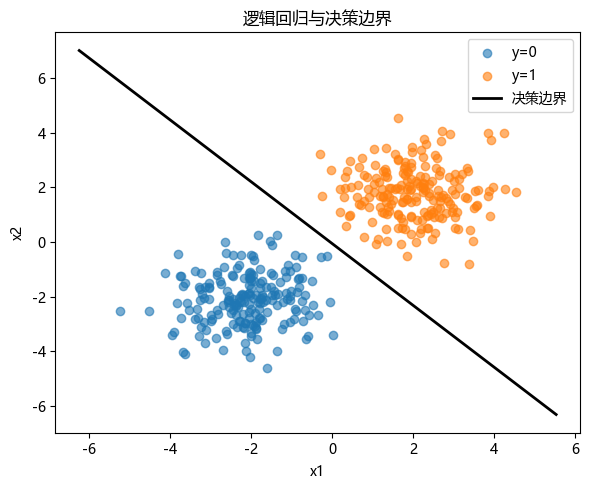

测试集（100 样本）准确率: 1.0


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from pathlib import Path

def _use_chinese_font():
    plt.rcParams["axes.unicode_minus"] = False
    for fp in ("C:/Windows/Fonts/msyh.ttc", "C:/Windows/Fonts/simhei.ttf", "C:/Windows/Fonts/simsun.ttc"):
        p = Path(fp)
        if p.is_file():
            try:
                fm.fontManager.addfont(str(p))
                name = fm.FontProperties(fname=str(p)).get_name()
                plt.rcParams["font.sans-serif"] = [name]
                plt.rcParams["font.family"] = name
                return
            except Exception:
                pass
    for f in fm.fontManager.ttflist:
        if any(k in f.name for k in ("YaHei", "SimHei", "SimSun")):
            plt.rcParams["font.sans-serif"] = [f.name]
            return


_use_chinese_font()


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


def binary_cross_entropy(y, p, eps=1e-15):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


rng = np.random.default_rng(7)
n_per = 200
# 两类线性可分：类0 中心 (-2,-2)，类1 中心 (2,2)
X0 = rng.standard_normal((n_per, 2)) + np.array([-2.0, -2.0])
X1 = rng.standard_normal((n_per, 2)) + np.array([2.0, 2.0])
X = np.vstack([X0, X1])
y = np.array([0] * n_per + [1] * n_per).reshape(-1, 1)

n_samples, n_feat = X.shape
W = rng.standard_normal((n_feat, 1)) * 0.01
b = np.zeros((1, 1))

lr = 0.1
n_iter = 1000

for t in range(n_iter):
    z = X @ W + b
    p = sigmoid(z)
    grad_W = X.T @ (p - y) / n_samples
    grad_b = np.mean(p - y, axis=0, keepdims=True)
    W -= lr * grad_W
    b -= lr * grad_b

# 决策边界: w0 x0 + w1 x1 + b = 0 -> x1 = -(w0 x0 + b)/w1
w0, w1 = float(W[0, 0]), float(W[1, 0])
bb = float(b[0, 0])
print("学习得到 w =", W.ravel(), "b =", bb)

plt.figure(figsize=(6, 5))
plt.scatter(X0[:, 0], X0[:, 1], alpha=0.6, label="y=0")
plt.scatter(X1[:, 0], X1[:, 1], alpha=0.6, label="y=1")
x_line = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
if abs(w1) > 1e-8:
    y_line = -(w0 * x_line + bb) / w1
    plt.plot(x_line, y_line, "k-", lw=2, label="决策边界")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("逻辑回归与决策边界")
plt.tight_layout()
plt.show()

# 测试集：新生成 100 个点（每类 50）
X0_te = rng.standard_normal((50, 2)) + np.array([-2.0, -2.0])
X1_te = rng.standard_normal((50, 2)) + np.array([2.0, 2.0])
X_te = np.vstack([X0_te, X1_te])
y_te = np.array([0] * 50 + [1] * 50).reshape(-1, 1)
p_te = sigmoid(X_te @ W + b)
y_hat = (p_te >= 0.5).astype(int)
acc = (y_hat == y_te).mean()
print("测试集（100 样本）准确率:", acc.item())